In [1]:
# =========================
# 1. SETUP
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from google.colab import drive
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

drive.mount('/content/drive')

SAVE_PATH = "/content/drive/MyDrive/best_pruned_model.pth"

# =========================
# 2. DATASET (WITH NORMALIZATION)
# =========================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                          shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=128,
                                         shuffle=False)

# =========================
# 3. PRUNABLE LAYER
# =========================
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # IMPORTANT: good initialization
        self.gate_scores = nn.Parameter(torch.ones_like(self.weight) * 2)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weight = self.weight * gates
        return torch.nn.functional.linear(x, pruned_weight, self.bias)

# =========================
# 4. MODEL
# =========================
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            PrunableLinear(3072, 1024),
            nn.ReLU(),
            PrunableLinear(1024, 512),
            nn.ReLU(),
            PrunableLinear(512, 10)
        )

    def forward(self, x):
        return self.net(x)

# =========================
# 5. SPARSITY LOSS
# =========================
def compute_sparsity_loss(model):
    loss = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += torch.sum(gates)
    return loss

# =========================
# 6. EVALUATION
# =========================
def evaluate(model):
    model.eval()
    correct = 0
    total = 0
    total_gates = 0
    zero_gates = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Calculate sparsity
        for module in model.modules():
            if isinstance(module, PrunableLinear):
                gates = torch.sigmoid(module.gate_scores)
                total_gates += gates.numel()
                zero_gates += (gates < 1e-2).sum().item()

    acc = 100 * correct / total
    sparsity = 100 * zero_gates / total_gates

    return acc, sparsity

# =========================
# 7. TRAINING FUNCTION
# =========================
def train_model(lambda_val):
    model = PrunableNet().to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    epochs = 50

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            ce_loss = criterion(outputs, labels)

            # DELAY PRUNING (CRUCIAL FIX)
            if epoch > 5:
                sparsity_loss = compute_sparsity_loss(model)
                loss = ce_loss + lambda_val * sparsity_loss
            else:
                loss = ce_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

    return model

# =========================
# 8. TRAIN WITH MULTIPLE LAMBDAS
# =========================
lambdas = [5e-6, 1e-5, 5e-5]

best_acc = 0

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")

    model = train_model(lam)
    acc, sparsity = evaluate(model)

    print(f"Accuracy: {acc:.2f}%, Sparsity: {sparsity:.2f}%")

    # Save best model
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), SAVE_PATH)
        print("✅ Best model updated & saved to Google Drive!")

print("\n🎯 Training Complete!")

Mounted at /content/drive


100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]



Training with lambda = 5e-06
Epoch 1, Loss: 643.3400
Epoch 2, Loss: 553.8914
Epoch 3, Loss: 505.0119
Epoch 4, Loss: 462.5303
Epoch 5, Loss: 424.3615
Epoch 6, Loss: 387.8185
Epoch 7, Loss: 6443.6864
Epoch 8, Loss: 5963.5495
Epoch 9, Loss: 5476.8342
Epoch 10, Loss: 5025.8616
Epoch 11, Loss: 4628.7914
Epoch 12, Loss: 4286.9115
Epoch 13, Loss: 3994.8063
Epoch 14, Loss: 3742.4013
Epoch 15, Loss: 3523.3384
Epoch 16, Loss: 3333.7080
Epoch 17, Loss: 3160.0639
Epoch 18, Loss: 3011.0080
Epoch 19, Loss: 2873.0580
Epoch 20, Loss: 2748.9843
Epoch 21, Loss: 2637.8333
Epoch 22, Loss: 2531.5588
Epoch 23, Loss: 2439.7396
Epoch 24, Loss: 2352.7422
Epoch 25, Loss: 2272.6473
Epoch 26, Loss: 2194.0004
Epoch 27, Loss: 2121.5542
Epoch 28, Loss: 2059.3698
Epoch 29, Loss: 1992.0140
Epoch 30, Loss: 1938.3141
Epoch 31, Loss: 1885.6453
Epoch 32, Loss: 1827.9419
Epoch 33, Loss: 1774.2421
Epoch 34, Loss: 1728.3596
Epoch 35, Loss: 1690.6180
Epoch 36, Loss: 1642.4455
Epoch 37, Loss: 1603.6053
Epoch 38, Loss: 1562.16

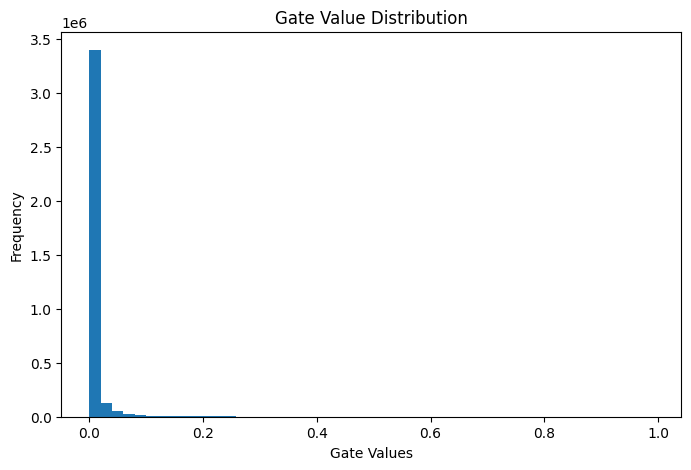

In [3]:
# =========================
# 9. GATE DISTRIBUTION PLOT
# =========================
import matplotlib.pyplot as plt

def plot_gate_distribution(model):
    all_gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy().flatten()
            all_gates.extend(gates)

    plt.figure(figsize=(8,5))
    plt.hist(all_gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Values")
    plt.ylabel("Frequency")

    # Save plot
    os.makedirs("results", exist_ok=True)
    plt.savefig("results/gate_distribution.png")

    plt.show()

# Call this AFTER best model training
plot_gate_distribution(model)